# Visualizing `batch_15_notices.json` in a pandas DataFrame

This notebook loads the synthetic notices JSON file into a pandas DataFrame and shows a few basic summaries and visualizations for quick inspection.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
# Load JSON file into a pandas DataFrame
base_dir = Path.cwd()
print(base_dir)
json_path = base_dir / "output" / "LLM_generated" / "batch_15_notices.json"

with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

# `notices` is the list we care about for tabular analysis
notices = data["notices"]

# Create a DataFrame
notices_df = pd.DataFrame(notices)

notices_df.head()

c:\Users\Andres.DESKTOP-D77KM25\OneDrive - Stanford\2021 - 2025\2025-2026\AI for Legal Help\repo\law809e\synthetic_notices


,text,defects,is_valid,metadata
0,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
1,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
2,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
3,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None
4,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None


In [ ]:
# Create one-hot defect indicator columns (1 = present, 0 = absent)

# Get the set of all unique defect codes across the dataset
all_defects = sorted({d for row in notices_df["defects"] for d in row})

for defect in all_defects:
    col_name = f"defect__{defect}"
    notices_df[col_name] = notices_df["defects"].apply(lambda ds: int(defect in ds))

# Inspect the updated DataFrame with defect indicator columns
notices_df.head()

,text,defects,is_valid,metadata,defect__financial_institution_incomplete,defect__insufficient_period,defect__missing_payee_info,defect__missing_payment_hours,defect__no_amount_stated,defect__no_forfeiture,defect__not_disjunctive,defect__rent_over_one_year
0,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
1,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
2,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
3,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
4,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0


In [ ]:
notices_df

,text,defects,is_valid,metadata,defect__financial_institution_incomplete,defect__insufficient_period,defect__missing_payee_info,defect__missing_payment_hours,defect__no_amount_stated,defect__no_forfeiture,defect__not_disjunctive,defect__rent_over_one_year
0,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
1,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
2,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
3,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
4,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
5,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
6,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[],True,None,0,0,0,0,0,0,0,0
7,3-DAY NOTICE TO PAY RENT AND QUIT\n\nDate: Oct...,"[no_amount_stated, not_disjunctive]",False,None,0,0,0,0,1,0,1,0
8,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,[insufficient_period],False,None,0,1,0,0,0,0,0,0
9,3-DAY NOTICE TO PAY RENT OR QUIT\n\nDate: Octo...,"[no_forfeiture, missing_payee_info]",False,None,0,0,1,0,0,1,0,0


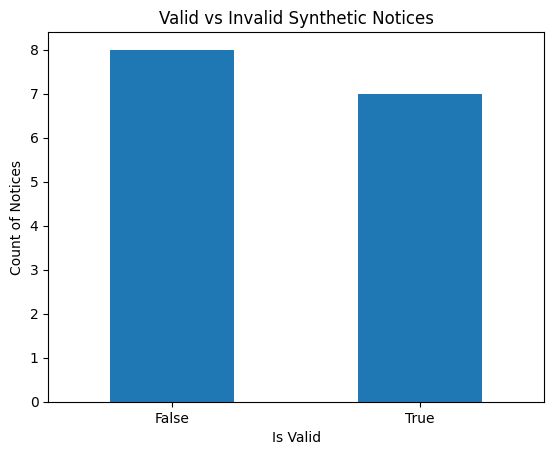

is_valid
False    8
True     7
Name: count, dtype: int64

In [8]:
# Basic validity breakdown
valid_counts = notices_df["is_valid"].value_counts().sort_index()

ax = valid_counts.plot(kind="bar", rot=0)
ax.set_xlabel("Is Valid")
ax.set_ylabel("Count of Notices")
ax.set_title("Valid vs Invalid Synthetic Notices")
plt.show()

valid_counts

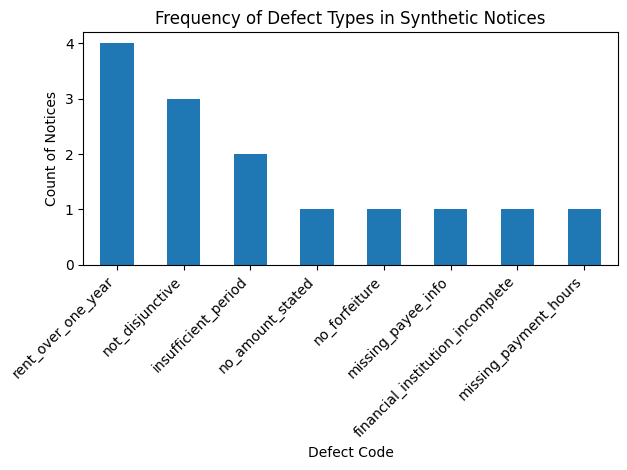

defects
rent_over_one_year                  4
not_disjunctive                     3
insufficient_period                 2
no_amount_stated                    1
no_forfeiture                       1
missing_payee_info                  1
financial_institution_incomplete    1
missing_payment_hours               1
Name: count, dtype: int64

In [9]:
# Frequency of each defect type (for invalid notices)
# `defects` is a list column; we "explode" it so each defect gets its own row

defects_exploded = notices_df.explode("defects")

# Filter out rows where `defects` is null (i.e., valid notices)
non_null_defects = defects_exploded[defects_exploded["defects"].notna()]

defect_counts = non_null_defects["defects"].value_counts()

ax = defect_counts.plot(kind="bar")
ax.set_xlabel("Defect Code")
ax.set_ylabel("Count of Notices")
ax.set_title("Frequency of Defect Types in Synthetic Notices")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

defect_counts

In [16]:
import os
print(os.getcwd())
notices_df.to_csv("batch_15_notices.csv", index=False)

c:\Users\Andres.DESKTOP-D77KM25\OneDrive - Stanford\2021 - 2025\2025-2026\AI for Legal Help\repo\law809e\synthetic_notices
